# BR-101 EDA Runbook: Step 7

This notebook-style script consumes the artifacts generated by
previous EDA steps and performs the categorical EDA
requested in runbook step 7 for occurrence-level data only.

Inputs expected under `data/silver/eda_runbook`:
- `canonical_accidents.parquet`
- `manual_exclusions.parquet`

Outputs written back to the same artifact directory:
- category summaries
- grouped plot inputs
- model-ready aggregate tables
- GLM coefficient tables


In [5]:
from pathlib import Path
from datetime import timedelta

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)


def resolve_project_root() -> Path:
    candidates: list[Path] = []
    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parents[1])

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, cwd.parent])

    for candidate in candidates:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError("Could not resolve the project root.")


PROJECT_ROOT = resolve_project_root()
ARTIFACTS_DIR = PROJECT_ROOT / "data" / "silver" / "eda_runbook"

CATEGORY_COLUMNS = [
    "dia_semana",
    "fase_dia",
    "condicao_metereologica",
    "holiday_status",
]

sns.set_theme(style="whitegrid")

import statsmodels.api as sm
import statsmodels.formula.api as smf


def save_frame(df: pd.DataFrame, name: str, *, index: bool = False) -> None:
    parquet_path = ARTIFACTS_DIR / f"{name}.parquet"
    csv_path = ARTIFACTS_DIR / f"{name}.csv"
    df.to_parquet(parquet_path, index=index)
    df.to_csv(csv_path, index=index)


def apply_manual_exclusions(
    df: pd.DataFrame,
    exclusions: pd.DataFrame,
    *,
    column_name: str,
) -> pd.DataFrame:
    active = exclusions.loc[exclusions[column_name].fillna(False), ["uf", "year", column_name]].copy()
    active[column_name] = True
    merged = df.merge(active, on=["uf", "year"], how="left")
    exclusion_mask = merged[column_name].fillna(False).to_numpy(dtype=bool)
    return merged.loc[~exclusion_mask].drop(columns=[column_name], errors="ignore")


def build_holiday_lookup(df: pd.DataFrame) -> pd.DataFrame:
    lookup = df[["uf", "accident_date"]].dropna().drop_duplicates().copy()
    cache: dict[tuple[str, int], holidays.HolidayBase] = {}

    def classify(row: pd.Series) -> str:
        uf = str(row["uf"])
        date_value = row["accident_date"]
        cache_key = (uf, date_value.year)
        if cache_key not in cache:
            cache[cache_key] = holidays.Brazil(years=[date_value.year], subdiv=uf)

        holiday_calendar = cache[cache_key]
        if date_value in holiday_calendar:
            return "holiday"
        if date_value + timedelta(days=1) in holiday_calendar:
            return "holiday_eve"
        if date_value - timedelta(days=1) in holiday_calendar:
            return "day_after_holiday"
        return "regular_day"

    lookup["holiday_status"] = lookup.apply(classify, axis=1)
    return lookup


def summarize_by_category(df: pd.DataFrame, category: str) -> pd.DataFrame:
    summary = (
        df.groupby(category, dropna=False)
        .agg(
            accident_count=("id", "size"),
            fatal_victims=("mortos", "sum"),
            people_involved=("pessoas", "sum"),
            fatal_accident_count=("has_fatality_occ", "sum"),
        )
        .reset_index()
    )
    summary["variable"] = category
    summary["fatal_victim_share"] = np.where(
        summary["people_involved"] > 0,
        summary["fatal_victims"] / summary["people_involved"],
        np.nan,
    )
    summary["fatal_accident_share"] = np.where(
        summary["accident_count"] > 0,
        summary["fatal_accident_count"] / summary["accident_count"],
        np.nan,
    )
    return summary[
        [
            "variable",
            category,
            "accident_count",
            "fatal_victims",
            "people_involved",
            "fatal_accident_count",
            "fatal_victim_share",
            "fatal_accident_share",
        ]
    ]


def prepare_statsmodels_frame(df: pd.DataFrame) -> pd.DataFrame:
    prepared = df.copy()
    prepared = prepared.dropna(
        subset=[
            "uf",
            "year",
            "dia_semana",
            "fase_dia",
            "condicao_metereologica",
            "holiday_status",
        ]
    )

    prepared["year"] = pd.to_numeric(prepared["year"], errors="coerce")
    prepared = prepared.dropna(subset=["year"])
    prepared["year"] = prepared["year"].astype("int64")

    for column in ["uf", "dia_semana", "fase_dia", "condicao_metereologica", "holiday_status"]:
        prepared[column] = prepared[column].astype(str)

    for column in [
        "accident_count",
        "fatal_victims",
        "people_involved",
        "fatal_accident_count",
        "fatal_victim_share",
        "fatal_accident_share",
    ]:
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce")

    return prepared


## Load step 1-6 artifacts and apply manual exclusions

In [6]:
canonical_accidents = pd.read_parquet(ARTIFACTS_DIR / "canonical_accidents.parquet")
manual_exclusions = pd.read_parquet(ARTIFACTS_DIR / "manual_exclusions.parquet")

print(f"Canonical accidents loaded: {len(canonical_accidents):,}")
print(f"Manual exclusion rows loaded: {len(manual_exclusions):,}")

Canonical accidents loaded: 106,254
Manual exclusion rows loaded: 270


In [7]:
analysis_df = canonical_accidents.copy()
analysis_df["timestamp"] = pd.to_datetime(analysis_df["timestamp"], errors="coerce")
analysis_df["accident_date"] = analysis_df["timestamp"].dt.date
analysis_df["year"] = pd.to_numeric(analysis_df["year"], errors="coerce").astype("Int64")
analysis_df["mortos"] = pd.to_numeric(analysis_df["mortos"], errors="coerce").fillna(0)
analysis_df["pessoas"] = pd.to_numeric(analysis_df["pessoas"], errors="coerce").fillna(0)
analysis_df["fatal_victims_occ"] = pd.to_numeric(
    analysis_df["fatal_victims_occ"], errors="coerce"
).fillna(0)
analysis_df["has_fatality_occ"] = analysis_df["mortos"].gt(0)

analysis_df = apply_manual_exclusions(
    analysis_df,
    manual_exclusions,
    column_name="exclude_from_descriptive",
)

print(f"Accidents retained for step 7 descriptive EDA: {len(analysis_df):,}")

Accidents retained for step 7 descriptive EDA: 103,248


## Derive holiday status and clean the core categorical variables

In [8]:
holiday_lookup = build_holiday_lookup(analysis_df)
analysis_df = analysis_df.merge(holiday_lookup, on=["uf", "accident_date"], how="left")
analysis_df["holiday_status"] = analysis_df["holiday_status"].fillna("unknown")

for column in ["dia_semana", "fase_dia", "condicao_metereologica"]:
    analysis_df[column] = analysis_df[column].astype("string").str.strip().fillna("unknown")

analysis_df["fatal_victim_share_in_accident"] = np.where(
    analysis_df["pessoas"] > 0,
    analysis_df["mortos"] / analysis_df["pessoas"],
    np.nan,
)

analysis_df[
    [
        "id",
        "uf",
        "timestamp",
        "dia_semana",
        "fase_dia",
        "condicao_metereologica",
        "holiday_status",
        "mortos",
        "pessoas",
    ]
].head()

,id,uf,timestamp,dia_semana,fase_dia,condicao_metereologica,holiday_status,mortos,pessoas
0,69.0,BA,2017-01-01 04:40:00,domingo,Amanhecer,Nublado,holiday,1,5
1,192.0,PE,2017-01-01 15:55:00,domingo,Pleno dia,Céu Claro,holiday,0,3
2,217.0,ES,2017-01-01 18:10:00,domingo,Pleno dia,Céu Claro,holiday,0,11
3,237.0,AL,2017-01-01 17:15:00,domingo,Anoitecer,Nublado,holiday,0,1
4,257.0,SC,2017-01-01 18:40:00,domingo,Pleno dia,Chuva,holiday,0,5


## One-way summaries for the main categorical variables

In [9]:
category_summaries = pd.concat(
    [summarize_by_category(analysis_df, category) for category in CATEGORY_COLUMNS],
    ignore_index=True,
)
save_frame(category_summaries, "step7_category_summaries")

category_summaries.head(20)

,variable,dia_semana,accident_count,fatal_victims,people_involved,fatal_accident_count,fatal_victim_share,fatal_accident_share,fase_dia,condicao_metereologica,holiday_status
0,dia_semana,domingo,15905,1135,38765,980,0.029279,0.061616,<NA>,<NA>,NaN
1,dia_semana,quarta-feira,13229,687,31642,596,0.021712,0.045053,<NA>,<NA>,NaN
2,dia_semana,quinta-feira,13778,731,32776,623,0.022303,0.045217,<NA>,<NA>,NaN
3,dia_semana,segunda-feira,14623,797,34825,707,0.022886,0.048348,<NA>,<NA>,NaN
4,dia_semana,sexta-feira,16091,872,39151,772,0.022273,0.047977,<NA>,<NA>,NaN
5,dia_semana,sábado,16575,1095,39687,961,0.027591,0.057979,<NA>,<NA>,NaN
6,dia_semana,terça-feira,13047,651,31126,586,0.020915,0.044915,<NA>,<NA>,NaN
7,fase_dia,<NA>,4134,388,9125,342,0.042521,0.082729,Amanhecer,<NA>,NaN
8,fase_dia,<NA>,5384,309,13351,276,0.023144,0.051263,Anoitecer,<NA>,NaN
9,fase_dia,<NA>,35330,3048,81737,2734,0.037290,0.077385,Plena Noite,<NA>,NaN


## Time-sliced summaries for descriptive plotting

In [10]:
category_year_summaries: list[pd.DataFrame] = []
for category in CATEGORY_COLUMNS:
    grouped = (
        analysis_df.groupby(["year", category], dropna=False)
        .agg(
            accident_count=("id", "size"),
            fatal_victims=("mortos", "sum"),
            people_involved=("pessoas", "sum"),
            fatal_accident_count=("has_fatality_occ", "sum"),
        )
        .reset_index()
    )
    grouped["variable"] = category
    grouped["fatal_victim_share"] = np.where(
        grouped["people_involved"] > 0,
        grouped["fatal_victims"] / grouped["people_involved"],
        np.nan,
    )
    grouped["fatal_accident_share"] = np.where(
        grouped["accident_count"] > 0,
        grouped["fatal_accident_count"] / grouped["accident_count"],
        np.nan,
    )
    category_year_summaries.append(grouped)

category_year_summaries_df = pd.concat(category_year_summaries, ignore_index=True)
save_frame(category_year_summaries_df, "step7_category_year_summaries")

category_year_summaries_df.head(20)

,year,dia_semana,accident_count,fatal_victims,people_involved,fatal_accident_count,variable,fatal_victim_share,fatal_accident_share,fase_dia,condicao_metereologica,holiday_status
0,2017,domingo,2163,145,4999,118,dia_semana,0.029006,0.054554,<NA>,<NA>,NaN
1,2017,quarta-feira,1578,81,3616,64,dia_semana,0.022400,0.040558,<NA>,<NA>,NaN
2,2017,quinta-feira,1776,92,4045,59,dia_semana,0.022744,0.033221,<NA>,<NA>,NaN
3,2017,segunda-feira,1814,103,4132,90,dia_semana,0.024927,0.049614,<NA>,<NA>,NaN
4,2017,sexta-feira,1987,102,4619,93,dia_semana,0.022083,0.046804,<NA>,<NA>,NaN
5,2017,sábado,2265,156,5221,128,dia_semana,0.029879,0.056512,<NA>,<NA>,NaN
6,2017,terça-feira,1585,58,3662,54,dia_semana,0.015838,0.034069,<NA>,<NA>,NaN
7,2018,domingo,1629,103,4139,94,dia_semana,0.024885,0.057704,<NA>,<NA>,NaN
8,2018,quarta-feira,1396,61,3340,48,dia_semana,0.018263,0.034384,<NA>,<NA>,NaN
9,2018,quinta-feira,1472,77,3451,68,dia_semana,0.022312,0.046196,<NA>,<NA>,NaN


## First-pass plots

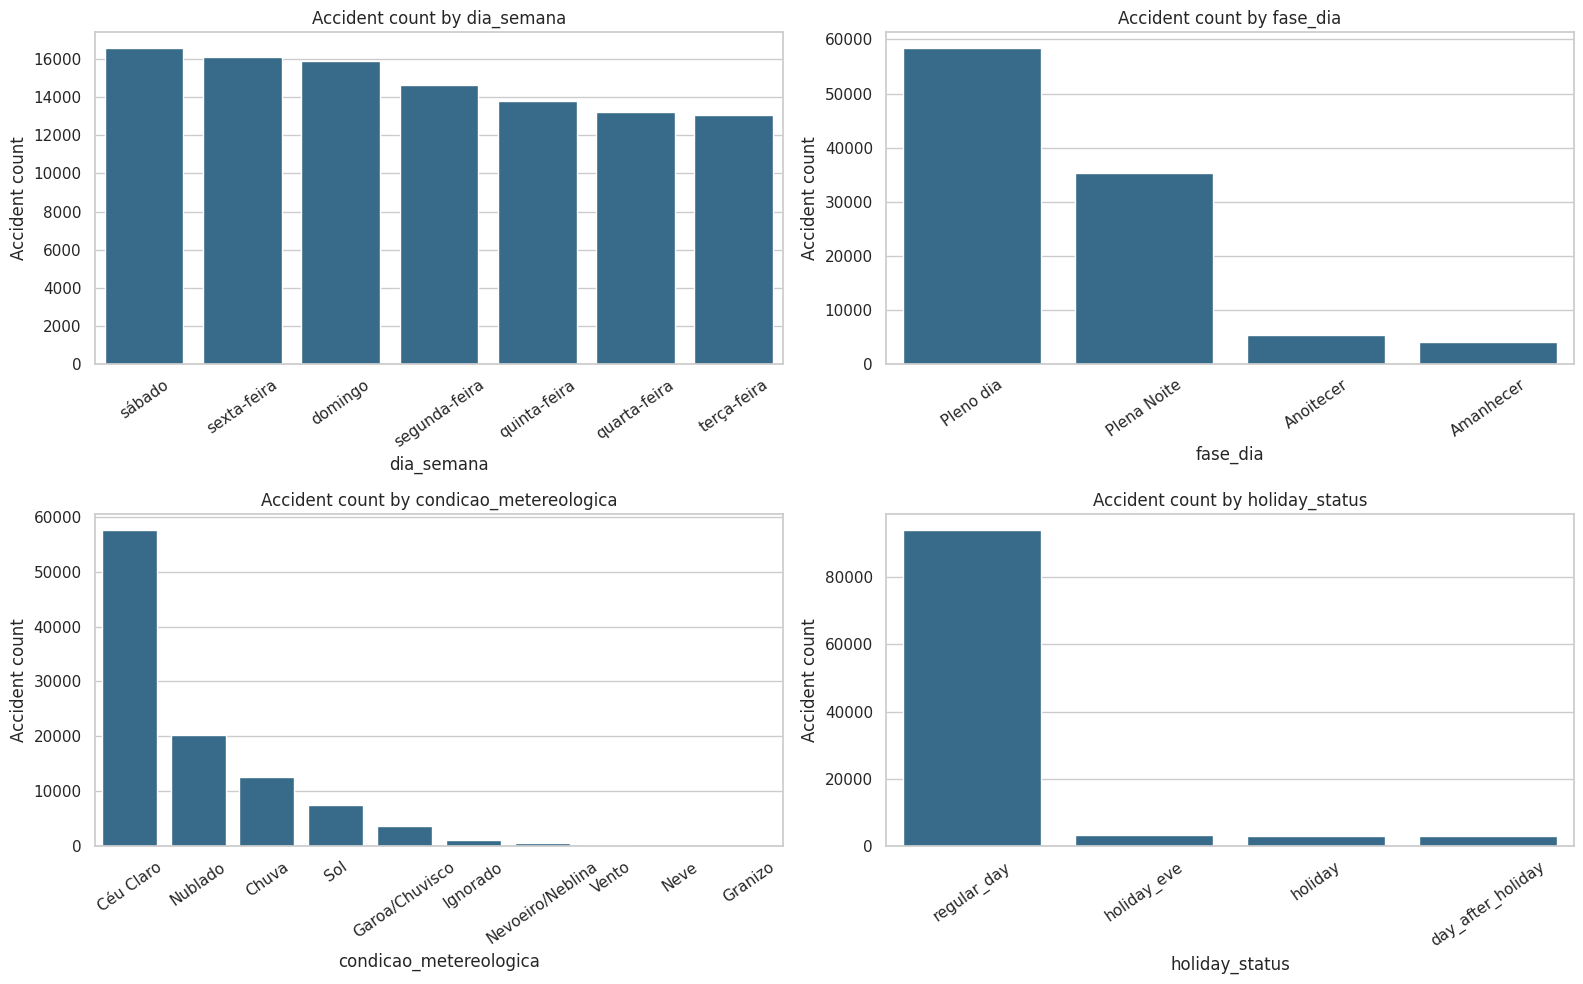

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for axis, category in zip(axes, CATEGORY_COLUMNS, strict=False):
    plot_df = category_summaries.loc[category_summaries["variable"].eq(category)].copy()
    plot_df = plot_df.sort_values("accident_count", ascending=False).head(12)
    sns.barplot(data=plot_df, x=category, y="accident_count", ax=axis, color="#2a6f97")
    axis.set_title(f"Accident count by {category}")
    axis.set_xlabel(category)
    axis.set_ylabel("Accident count")
    axis.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

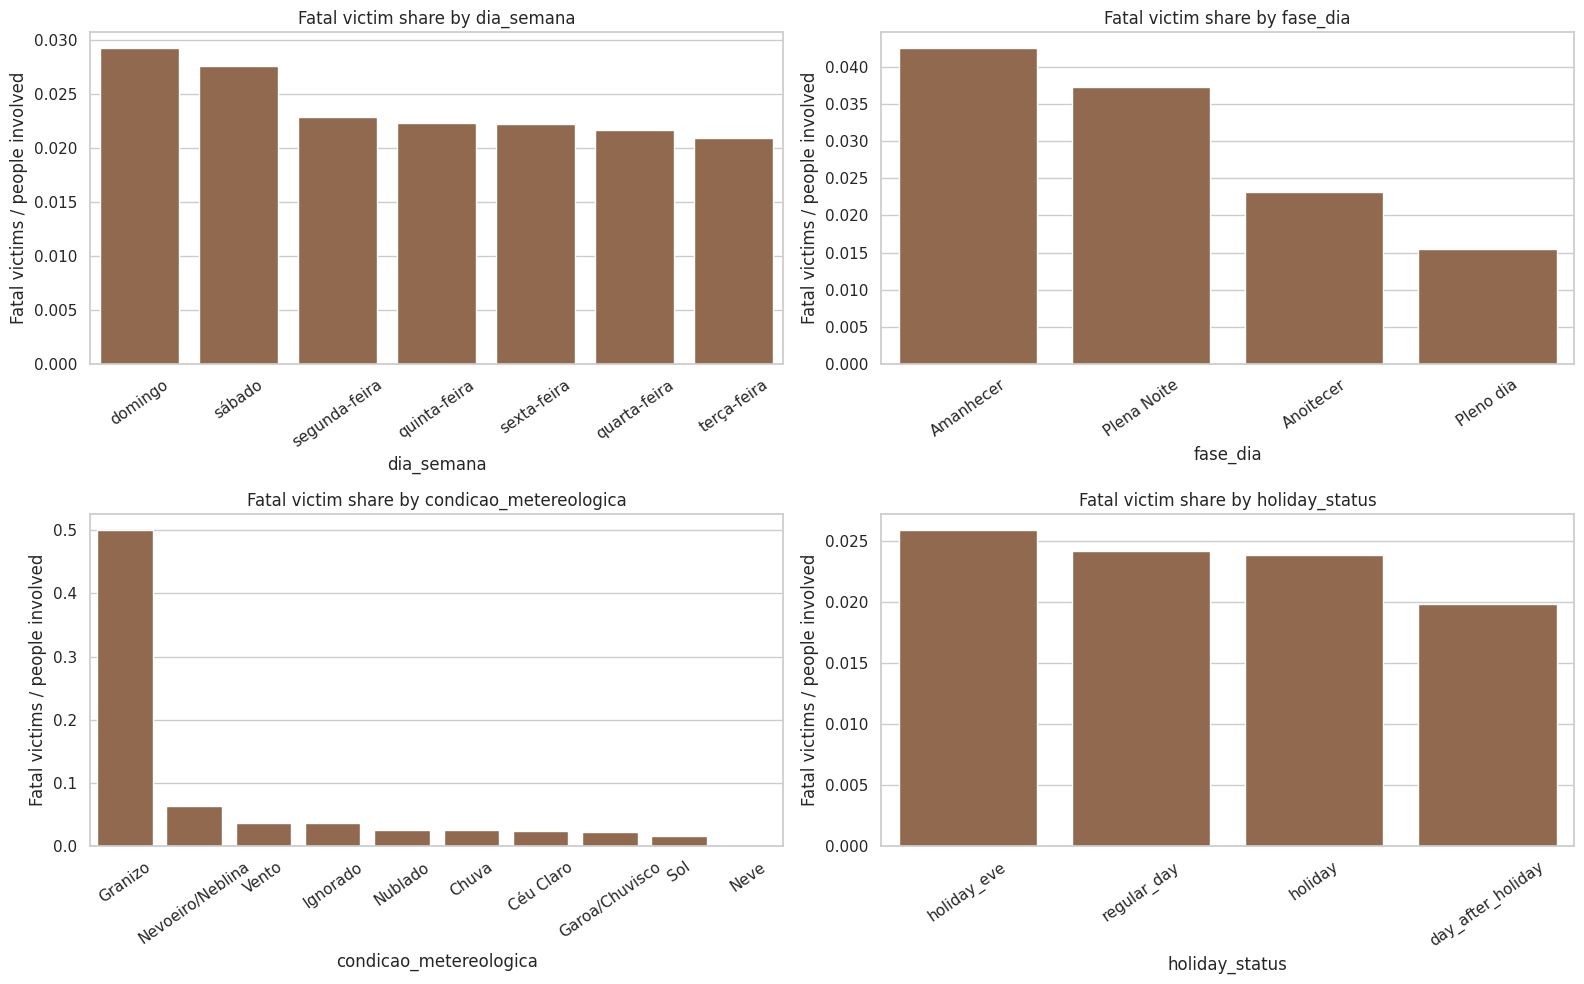

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for axis, category in zip(axes, CATEGORY_COLUMNS, strict=False):
    plot_df = category_summaries.loc[category_summaries["variable"].eq(category)].copy()
    plot_df = plot_df.sort_values("fatal_victim_share", ascending=False).head(12)
    sns.barplot(data=plot_df, x=category, y="fatal_victim_share", ax=axis, color="#9c6644")
    axis.set_title(f"Fatal victim share by {category}")
    axis.set_xlabel(category)
    axis.set_ylabel("Fatal victims / people involved")
    axis.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


## Model-ready aggregate tables for the count and severity questions


In [13]:
model_frame = (
    analysis_df.groupby(
        ["uf", "year", "dia_semana", "fase_dia", "condicao_metereologica", "holiday_status"],
        dropna=False,
    )
    .agg(
        accident_count=("id", "size"),
        fatal_victims=("mortos", "sum"),
        people_involved=("pessoas", "sum"),
        fatal_accident_count=("has_fatality_occ", "sum"),
    )
    .reset_index()
)
model_frame["fatal_victim_share"] = np.where(
    model_frame["people_involved"] > 0,
    model_frame["fatal_victims"] / model_frame["people_involved"],
    np.nan,
)
model_frame["fatal_accident_share"] = np.where(
    model_frame["accident_count"] > 0,
    model_frame["fatal_accident_count"] / model_frame["accident_count"],
    np.nan,
)

save_frame(model_frame, "step7_model_frame")
model_frame.head(20)

,uf,year,dia_semana,fase_dia,condicao_metereologica,holiday_status,accident_count,fatal_victims,people_involved,fatal_accident_count,fatal_victim_share,fatal_accident_share
0,AL,2017,domingo,Anoitecer,Céu Claro,regular_day,1,0,1,0,0.000000,0.000000
1,AL,2017,domingo,Anoitecer,Nublado,holiday,1,0,1,0,0.000000,0.000000
2,AL,2017,domingo,Anoitecer,Nublado,regular_day,1,0,1,0,0.000000,0.000000
3,AL,2017,domingo,Plena Noite,Chuva,regular_day,2,0,3,0,0.000000,0.000000
4,AL,2017,domingo,Plena Noite,Céu Claro,regular_day,21,3,45,3,0.066667,0.142857
5,AL,2017,domingo,Plena Noite,Ignorado,regular_day,1,0,2,0,0.000000,0.000000
6,AL,2017,domingo,Plena Noite,Nublado,holiday_eve,1,0,2,0,0.000000,0.000000
7,AL,2017,domingo,Plena Noite,Nublado,regular_day,5,2,19,2,0.105263,0.400000
8,AL,2017,domingo,Pleno dia,Chuva,regular_day,3,0,5,0,0.000000,0.000000
9,AL,2017,domingo,Pleno dia,Céu Claro,day_after_holiday,1,0,1,0,0.000000,0.000000


In [14]:
if sm is None or smf is None:
    print("statsmodels is not installed; skipping optional GLM cells.")
else:
    glm_model_frame = prepare_statsmodels_frame(model_frame)
    count_formula = (
        "accident_count ~ C(dia_semana) + C(fase_dia) + "
        "C(condicao_metereologica) + C(holiday_status) + C(year) + C(uf)"
    )
    count_model = smf.glm(
        formula=count_formula,
        data=glm_model_frame,
        family=sm.families.Poisson(),
    ).fit()

    count_coefficients = (
        count_model.summary2().tables[1].reset_index().rename(columns={"index": "term"})
    )
    save_frame(count_coefficients, "step7_poisson_coefficients")
    print(count_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         accident_count   No. Observations:                12924
Model:                            GLM   Df Residuals:                    12885
Model Family:                 Poisson   Df Model:                           38
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -30903.
Date:                Mon, 23 Mar 2026   Deviance:                       22506.
Time:                        11:02:59   Pearson chi2:                 3.00e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [15]:
if sm is None or smf is None:
    print("statsmodels is not installed; skipping optional GLM cells.")
else:
    glm_model_frame = prepare_statsmodels_frame(model_frame)
    severity_df = glm_model_frame.loc[glm_model_frame["people_involved"] > 0].copy()
    severity_formula = (
        "fatal_victim_share ~ C(dia_semana) + C(fase_dia) + "
        "C(condicao_metereologica) + C(holiday_status) + C(year) + C(uf)"
    )
    severity_model = smf.glm(
        formula=severity_formula,
        data=severity_df,
        family=sm.families.Binomial(),
        freq_weights=severity_df["people_involved"].to_numpy(dtype=float),
    ).fit()

    severity_coefficients = (
        severity_model.summary2().tables[1].reset_index().rename(columns={"index": "term"})
    )
    save_frame(severity_coefficients, "step7_severity_glm_coefficients")
    print(severity_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     fatal_victim_share   No. Observations:                12924
Model:                            GLM   Df Residuals:                   247933
Model Family:                Binomial   Df Model:                           38
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -21528.
Date:                Mon, 23 Mar 2026   Deviance:                       9724.6
Time:                        11:04:11   Pearson chi2:                 1.56e+04
No. Iterations:                    19   Pseudo R-squ. (CS):             0.1923
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------